## NOTE: scikit-learn has to be installed separately of the CNSistent environment

In [1]:
# set auto-reload of the notebook
%load_ext autoreload
%autoreload 2

import cns
import cns.data_utils as cdu
import pandas as pd
import matplotlib.pyplot as plt
import time
import numpy as np
from sklearn.manifold import MDS
from sklearn.metrics import silhouette_score


pd.set_option('display.max_columns', 10)
# set color_map to tab10
color_map = plt.cm.get_cmap('tab10').colors[:10]
plt.rcParams.update({'font.size': 12})

C:\Users\adams\AppData\Local\Temp\ipykernel_31544\296405123.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_map = plt.cm.get_cmap('tab10').colors[:10]


In [2]:
seg_size = "1MB"
seg_name = "1 Mb"
samples_df, cns_df = cdu.main_load(seg_size)
cns_df = cns.only_aut(cns.add_total_cn(cns_df))
subs_df = pd.concat([cns.select_cns_by_type(cns_df, samples_df, "LUAD"), cns.select_cns_by_type(cns_df, samples_df, "LUSC")])
luad_samples = samples_df[samples_df['type'] == 'LUAD'].index
lusc_samples = samples_df[samples_df['type'] == 'LUSC'].index

In [3]:

# Perform MDS on the pivoted data (if not already done)

data, rows, columns = cns.bins_to_features(subs_df, cn_columns='total_cn')
mds_naive_res = MDS(n_components=2, dissimilarity='euclidean', random_state=42).fit_transform(data)

c:\python311\Lib\site-packages\sklearn\manifold\_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
c:\python311\Lib\site-packages\sklearn\manifold\_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
c:\python311\Lib\site-packages\sklearn\manifold\_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


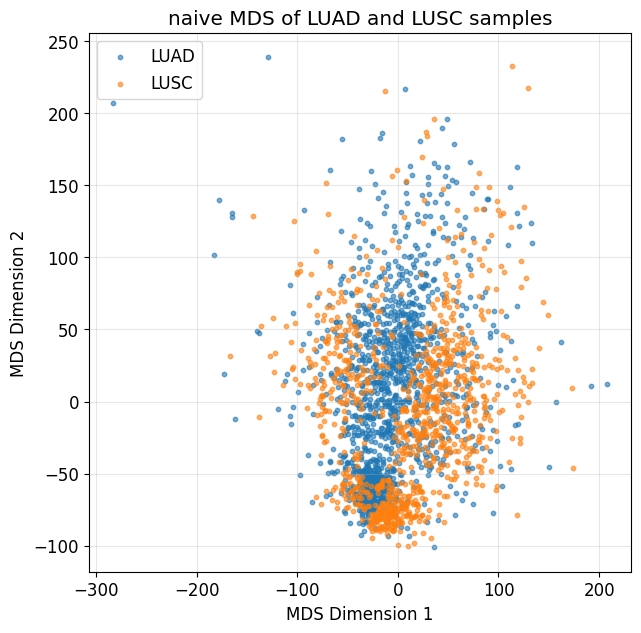

In [4]:
# Create a DataFrame for MDS results
naive_mds_df = pd.DataFrame(mds_naive_res, columns=['MDS1', 'MDS2'], index=rows)
naive_mds_df['type'] = samples_df.loc[naive_mds_df.index, 'type']

# Plot MDS results, coloring by sample type
plt.figure(figsize=(7, 7))
for i, t in enumerate(['LUAD', 'LUSC']):
	mask = naive_mds_df['type'] == t
	plt.scatter(naive_mds_df.loc[mask, 'MDS1'], naive_mds_df.loc[mask, 'MDS2'],
				label=t, color=color_map[i % len(color_map)], s=10, alpha=0.6)

plt.legend()
plt.xlabel('MDS Dimension 1')
plt.ylabel('MDS Dimension 2')
plt.title('naive MDS of LUAD and LUSC samples')
plt.grid(alpha=0.3)
cdu.save_cns_fig('naive_mds_luad_lusc')

In [5]:
start = time.time()
dist_matrix = cns.calc_distances(subs_df, "total_cn")
print(f"Elapsed time: {time.time() - start:.2f} seconds")
dist_matrix.to_csv(cdu.pjoin(cdu.out_path, "LUAD_LUSC_dist_matrix.tsv"), sep="\t", index=True, header=True)

Elapsed time: 38.50 seconds


In [6]:
# Get sample metadata (assuming samples_df has metadata we can use)
sample_metadata = samples_df.loc[dist_matrix.index]

# Perform MDS on the distance matrix
positions = MDS(n_components=2, dissimilarity='precomputed', random_state=42).fit_transform(dist_matrix.values)

# Create a DataFrame with MDS results
pre_mds_df = pd.DataFrame(positions, columns=['MDS1', 'MDS2'], index=dist_matrix.index)

# Merge with metadata (adjust this based on your actual metadata structure)
# If you have a 'type' or 'subtype' column that would be useful for coloring
if 'type' in sample_metadata.columns:  # Adjust column name as needed
    pre_mds_df['type'] = sample_metadata['type']

c:\python311\Lib\site-packages\sklearn\manifold\_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
c:\python311\Lib\site-packages\sklearn\manifold\_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
c:\python311\Lib\site-packages\sklearn\manifold\_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


In [7]:
# Calculate mean distance to LUAD and LUSC samples for each sample in dist_matrix
mean_dist_to_luad = dist_matrix.loc[luad_samples].mean(axis=0)
mean_dist_to_lusc = dist_matrix.loc[lusc_samples].mean(axis=0)

mean_dist_df = pd.DataFrame({
    'dist_luad': mean_dist_to_luad,
    'dist_lusc': mean_dist_to_lusc
})

mean_dist_df["type"] = samples_df["type"]
mean_dist_df["diff"] = np.where(mean_dist_df["type"] == "LUAD", mean_dist_df["dist_luad"] - mean_dist_df["dist_lusc"] , mean_dist_df["dist_lusc"] -  mean_dist_df["dist_luad"])
mean_dist_df

,dist_luad,dist_lusc,type,diff
sample_id,,,,
CRUK0001_SU_T1-R1,0.313019,0.353022,LUAD,-0.040003
CRUK0001_SU_T1-R2,0.332345,0.367163,LUAD,-0.034818
CRUK0001_SU_T1-R3,0.321791,0.348090,LUAD,-0.026299
CRUK0002_SU_T1-R1,0.363407,0.392694,LUAD,-0.029286
CRUK0002_SU_T1-R2,0.374275,0.399643,LUAD,-0.025368
...,...,...,...,...
TCGA-O2-A52W,0.403948,0.358278,LUSC,-0.045670
TCGA-O2-A5IB,0.387930,0.388498,LUSC,0.000569
TCGA-O2-A5IC,0.296605,0.317973,LUSC,0.021368


In [8]:
# Only calculate silhouette score if there are at least 2 clusters
labels = pre_mds_df['type'].values
sil_score = silhouette_score(pre_mds_df[['MDS1', 'MDS2']].values, labels)
print(f"Silhouette score (using sample type as clusters): {sil_score:.3f}")

Silhouette score (using sample type as clusters): 0.310


In [9]:
std = mean_dist_df["diff"].std()
outliers_df = mean_dist_df[mean_dist_df["diff"] < 0]
outliers_df.shape

(2066, 4)

2251 -47.42908294887233 1 44.159851185050734
Number of outliers: 57
LUSC outliers: 54
LUAD outliers: 3


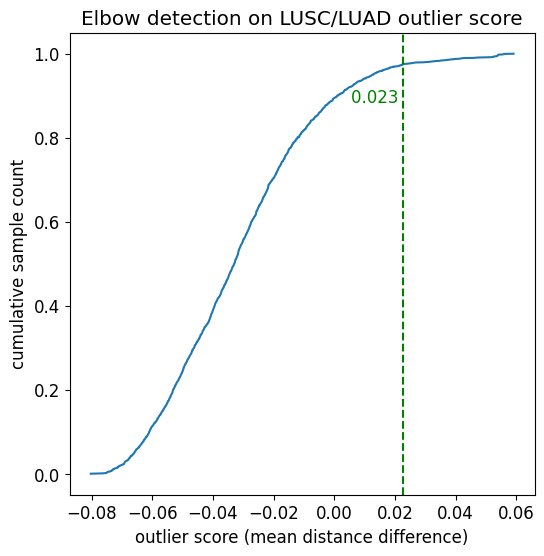

In [10]:
x, y, knee_pos, knee_val, elbow_pos, elbow_val = cns.find_bends(mean_dist_df.sort_values("diff")["diff"])
print(knee_pos, knee_val, elbow_pos, elbow_val)

plt.figure(figsize=(6, 6))
plt.plot(x, y)
plt.axvline(x=x[knee_pos], color='g', linestyle='--')
plt.text(x[knee_pos], y[knee_pos] - 0.1, f"{x[knee_pos]:.3f} ", color='g', va='bottom', ha='right', fontsize=12)
plt.ylabel("cumulative sample count")
plt.xlabel("outlier score (mean distance difference)")
plt.title("Elbow detection on LUSC/LUAD outlier score")
cdu.save_cns_fig("knee_elbow_mean_distance_diff")

std = mean_dist_df["diff"].std()
outliers_df = mean_dist_df[mean_dist_df["diff"] > x[knee_pos]]
outliers_df.shape

print(f"Number of outliers: {outliers_df.shape[0]}")
print(f"LUSC outliers: {outliers_df[outliers_df['type'] == 'LUSC'].shape[0]}")
print(f"LUAD outliers: {outliers_df[outliers_df['type'] == 'LUAD'].shape[0]}")

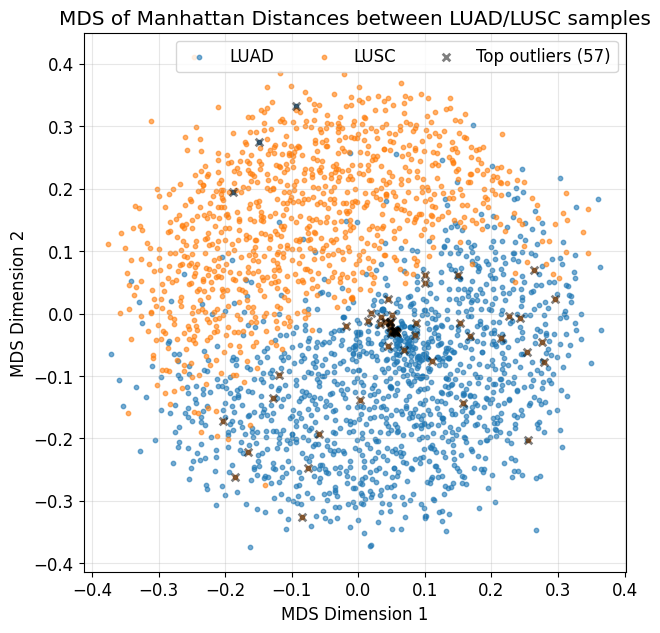

In [11]:
# Plot MDS results
plt.figure(figsize=(7, 7))

# If type information is available, use it for coloring
types = pre_mds_df['type'].unique()
for i, t in enumerate(types):
	mask = pre_mds_df['type'] == t
	plt.scatter(pre_mds_df.loc[mask, 'MDS1'], pre_mds_df.loc[mask, 'MDS2'], 
				label=t, color=color_map[i % len(color_map)], s=10, alpha=0.6)

plt.scatter(pre_mds_df.loc[outliers_df.index, 'MDS1'],
			pre_mds_df.loc[outliers_df.index, 'MDS2'],
			marker='x', color='black', s=30, alpha=.5, linewidths=2, label=f'Top outliers ({len(outliers_df)})')

plt.legend(ncols=3)
plt.xlabel('MDS Dimension 1')
plt.ylabel('MDS Dimension 2')
plt.title('MDS of Manhattan Distances between LUAD/LUSC samples')
plt.grid(alpha=0.3)

# Optionally save the MDS results
pre_mds_df.to_csv(cdu.pjoin(cdu.out_path, "LUAD_LUSC_mds_positions.tsv"), sep="\t", index=True)
cdu.save_cns_fig("LUAD_LUSC_mds_positions")

In [12]:
lusc_df = cns.select_CNS_samples(cns_df, samples_df.query("type == 'LUSC'"))
luad_df = cns.select_CNS_samples(cns_df, samples_df.query("type == 'LUAD'"))
lusc_outliers_df = cns.select_CNS_samples(cns_df, outliers_df.query("type == 'LUSC'"))
luad_outliers_df = cns.select_CNS_samples(cns_df, outliers_df.query("type == 'LUAD'"))

lusc_group = cns.group_samples(lusc_df, group_name=f"LUSC all ({lusc_df['sample_id'].nunique()})")
luad_group = cns.group_samples(luad_df,group_name=f"LUAD all ({luad_df['sample_id'].nunique()})")
lusc_outliers_group = cns.group_samples(lusc_outliers_df, group_name=f"LUSC outliers ({lusc_outliers_df['sample_id'].nunique()})")
luad_outliers_group = cns.group_samples(luad_outliers_df, group_name=f"LUAD outliers ({luad_outliers_df['sample_id'].nunique()})")

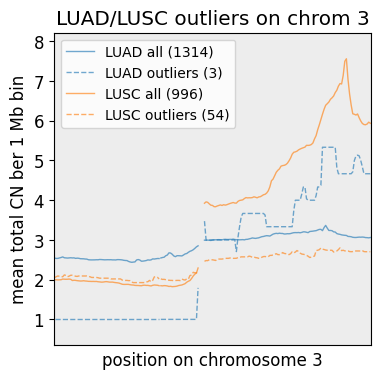

In [13]:
all_groups = pd.concat([lusc_group,  lusc_outliers_group, luad_group, luad_outliers_group])
fig, axs = cns.fig_lines(all_groups.query("chrom == 'chr3'"), cn_columns="total_cn", colors=[color_map[0], color_map[0], color_map[1], color_map[1]])
for i, line in enumerate(axs.lines):
	if i in [3, 4, 5, 9, 10, 11]:
		line.set_linestyle('--')
axs.legend(loc='upper left', ncol=1, fontsize=10)
fig.set_size_inches(4, 4)
plt.title("LUAD/LUSC outliers on chrom 3")
axs.set_xticks([cns.hg19.chr_starts["chr3"], cns.hg19.chr_starts["chr4"]])
axs.set_xticklabels([cns.hg19.chr_starts["chr3"], cns.hg19.chr_starts["chr4"]])
# nullify small ticks
axs.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
axs.set_xlabel("position on chromosome 3")
axs.set_ylabel(f"mean total CN ber {seg_name} bin")
cdu.save_cns_fig("LUAD_LUSC_outliers")

In [14]:
outlier_counts = outliers_df.merge(samples_df[["source"]], left_on="sample_id", right_index=True)["source"].value_counts().sort_index()
val_counts = samples_df.query("type == 'LUAD' or type == 'LUSC'")[["source"]].value_counts().sort_index()
print(outlier_counts)
print(val_counts)
# calculate the percentage of outliers in each source
fractions  = outlier_counts.values / val_counts.values
fractions_df = pd.DataFrame(fractions, index=outlier_counts.index, columns=["fraction"])
fractions_df = fractions_df.reset_index()
# Normalize fractions to sum to 1
fractions_df["fraction_norm"] = fractions_df["fraction"] / fractions_df["fraction"].sum()
print(fractions_df)

source
PCAWG         2
TCGA_hg19    43
TRACERx      12
Name: count, dtype: int64
source   
PCAWG          82
TCGA_hg19     906
TRACERx      1322
Name: count, dtype: int64
      source  fraction  fraction_norm
0      PCAWG  0.024390       0.301379
1  TCGA_hg19  0.047461       0.586459
2    TRACERx  0.009077       0.112162
